In [1]:
import ee
import geemap
import pandas as pd

ee.Initialize()

In [2]:
counties = ee.FeatureCollection("FAO/GAUL/2015/level2") # Load a collection of geographic features (polygons) from the dataset FAO/GAUL/2015/level2
# FAO Food and Agriculture Organization of the United Nations.
# GAUL Global Administrative Unit Layers
# It is simply a worldwide database of administrative boundaries.
# LeveL 2 = Second administrative division which is the level at which Makueni is displayed in this db

makueni = counties.filter(
    ee.Filter.And(
        ee.Filter.eq("ADM0_NAME", "Kenya"), # Administrative Level 0 = Country
        ee.Filter.eq("ADM2_NAME", "Makueni") # Administrative Level 2 = County
    )
)

In [3]:
months = pd.date_range(
    start="2020-01-01",
    end="2024-12-01",
    freq="MS" # MS means "Month Start", i.e., the first day of every month.
)

months

DatetimeIndex(['2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01',
               '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01',
               '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01',
               '2021-01-01', '2021-02-01', '2021-03-01', '2021-04-01',
               '2021-05-01', '2021-06-01', '2021-07-01', '2021-08-01',
               '2021-09-01', '2021-10-01', '2021-11-01', '2021-12-01',
               '2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01',
               '2022-05-01', '2022-06-01', '2022-07-01', '2022-08-01',
               '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01',
               '2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01',
               '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01',
               '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01',
               '2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
      

In [4]:
def monthly_mean_ndvi(start_date, end_date):
    
    s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(makueni)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    )
    
    image = s2.median().clip(makueni)

    ndvi = image.normalizedDifference(
        ["B8", "B4"]
    ).rename("NDVI")
    
    mean_ndvi = ndvi.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=makueni.geometry(),
        scale=10,                         # At what spatial resolution should I sample the image? 10 = Use the original Sentinel-2 resolution
        maxPixels=1e9                     # Earth Engine limits how many pixels you're allowed to process in one request. To prevent accidentally requesting billions of pixels over the whole planet, Earth Engine has a safety limit.
    )                                     # I authorize Earth Engine to process up to one billion pixels.

    return mean_ndvi.get("NDVI")

In [5]:
print(
    monthly_mean_ndvi(
        "2024-01-01",
        "2024-02-01"
    ).getInfo()
)

0.6316708595939606


In [6]:
results = []

for start in months:
    end = start + pd.DateOffset(months=1)

    value = monthly_mean_ndvi(
        start.strftime("%Y-%m-%d"), # strftime means “string format time.”
        end.strftime("%Y-%m-%d")
    ).getInfo()

    results.append({
        "month": start.strftime("%Y-%m"),
        "mean_ndvi": value
    })

    print(start.strftime("%Y-%m"), value)

2020-01 0.5854976306340175
2020-02 0.6261682415294061
2020-03 0.6025520684962182
2020-04 0.5547902025282629
2020-05 0.47890998653747396
2020-06 0.41688900921636407
2020-07 0.3379868034608708
2020-08 0.3032619740115891
2020-09 0.225909806820252
2020-10 0.28011690276920803
2020-11 0.38001226667468097
2020-12 0.6098014161655306
2021-01 0.5685876849378255
2021-02 0.535590759402741
2021-03 0.35721050157621465
2021-04 0.3186490676470196
2021-05 0.3384880116143697
2021-06 0.45698168189206195
2021-07 0.24314029468531728
2021-08 0.26657162058062817
2021-09 0.21073672091054832
2021-10 0.24128420450759877
2021-11 0.24612818799534286
2021-12 0.5557547983571111
2022-01 0.6434540418585312
2022-02 0.41969297652948656
2022-03 0.3645681287658784
2022-04 0.28968974415977716
2022-05 0.37586793052656664
2022-06 0.236011637977125
2022-07 0.29040991708985653
2022-08 0.19849032363785044
2022-09 0.2085324860293321
2022-10 0.20884101238599775
2022-11 0.1647842946455766
2022-12 0.5576078468769089
2023-01 0.4834

In [7]:
df = pd.DataFrame(results)
df

,month,mean_ndvi
0,2020-01,0.585498
1,2020-02,0.626168
2,2020-03,0.602552
3,2020-04,0.554790
4,2020-05,0.478910
5,2020-06,0.416889
6,2020-07,0.337987
7,2020-08,0.303262
8,2020-09,0.225910
9,2020-10,0.280117


<Axes: title={'center': 'Monthly Mean NDVI - Makueni County'}, xlabel='month'>

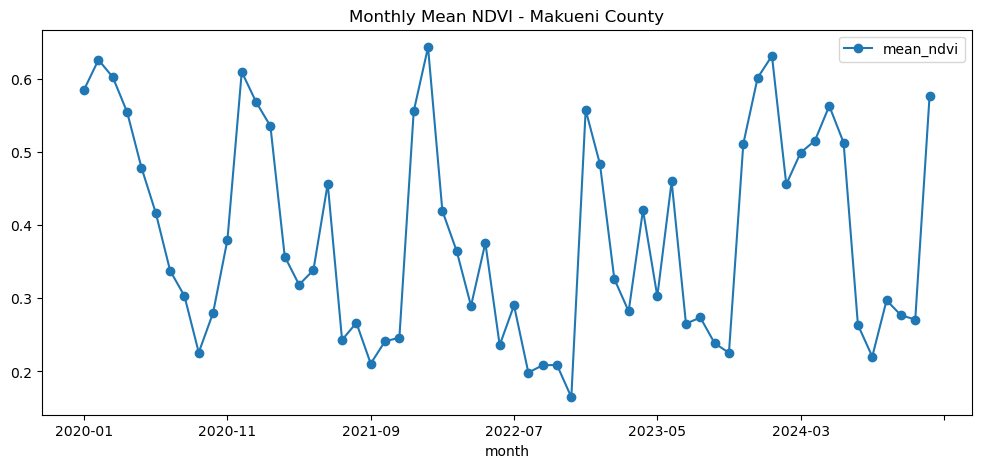

In [8]:
df.plot(
    x="month",
    y="mean_ndvi",
    marker="o",
    figsize=(12, 5),
    title="Monthly Mean NDVI - Makueni County"
)

In [9]:
df["month"] = pd.to_datetime(df["month"])

In [10]:
df.to_csv("../outputs/makueni_monthly_ndvi_2020_2024.csv", index=False)

In [11]:
df.head()

,month,mean_ndvi
0,2020-01-01,0.585498
1,2020-02-01,0.626168
2,2020-03-01,0.602552
3,2020-04-01,0.554790
4,2020-05-01,0.478910


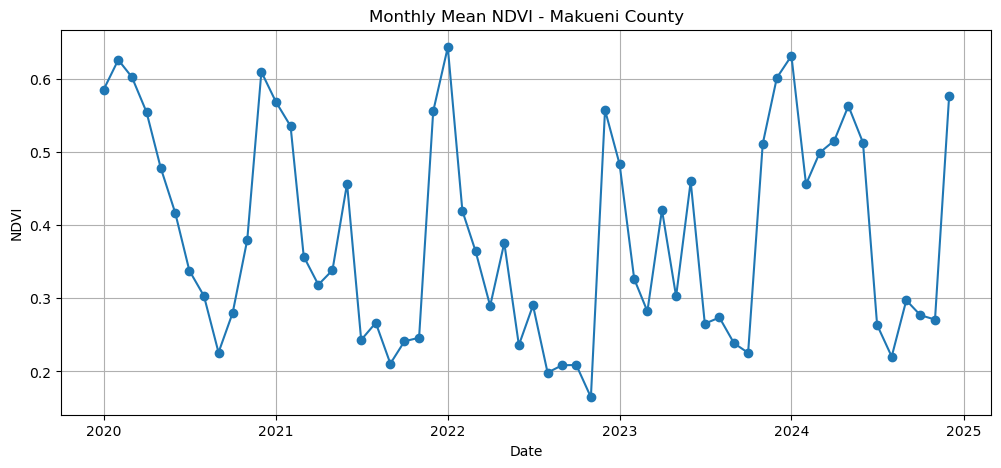

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["month"], df["mean_ndvi"], marker="o")
plt.title("Monthly Mean NDVI - Makueni County")
plt.ylabel("NDVI")
plt.xlabel("Date")
plt.grid(True)

plt.savefig(
    "../docs/images/makueni_ndvi_timeseries_2020_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()